In [9]:
from IPython.core.display import Markdown
from dotenv import load_dotenv
from langgraph.graph import StateGraph
from src.States import GlobalState, Car
from src.States import TrackData
from typing import *
import random
from langgraph.constants import START,END
from IPython.core.display import Image

load_dotenv()

True

In [10]:
MOCK_TRACK_DATA: List[TrackData] = [
    {
        "TrackID": 1,
        "TrackName": "Monaco",
        "Soft_Deg": 11.1,
        "Medium_Deg": 6.67,
        "Wet_Deg": 9.1,
    },
    {
        "TrackID": 2,
        "TrackName": "Great Britain",
        "Soft_Deg": 14.25,
        "Medium_Deg": 9.1,
        "Wet_Deg": 10,
    },
    {
        "TrackID": 3,
        "TrackName": "Abu Dhabi",
        "Soft_Deg": 16.25,
        "Medium_Deg": 8.25,
        "Wet_Deg": 8.5,
    },
]

MOCK_CAR_LIST: List[Car] = [
    {
        "CarPosition": 1,
        "CarID": 4,  # Lando Norris
        "Team": "McLaren",
        "Telemetry": None,
        "Driver": "Lando Norris",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 2,
        "CarID": 1,  # Max Verstappen
        "Team": "RedBull",
        "Telemetry": None,
        "Driver": "Max Verstappen",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 3,
        "CarID": 63,  # George Russell
        "Team": "Mercedes",
        "Telemetry": None,
        "Driver": "George Russell",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 4,
        "CarID": 81,  # Oscar Piastri
        "Team": "McLaren",
        "Telemetry": None,
        "Driver": "Oscar Piastri",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 5,
        "CarID": 12,  # Andrea Kimi Antonelli
        "Team": "Mercedes",
        "Telemetry": None,
        "Driver": "Andrea Kimi Antonelli",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
    {
        "CarPosition": 6,
        "CarID": 22,  # Yuki Tsunoda
        "Team": "RedBull",
        "Telemetry": None,
        "Driver": "Yuki Tsunoda",
        "TotalRaceTime": 0.0,
        "isUser": False,
    },
]

In [11]:
def select_track(state: GlobalState) -> dict:
    """This tool is used to select the user track and define it in all the global"""
    selection = int(input("Select Track: \n1. Monaco\n2. Great Britain\n3. Abu Dhabi\n"))
    while selection not in [1,2,3]:
        selection = int(input("Pls Select a Valid Track\nSelect Track: \n1. Monaco\n2. Great Britain\n3. Abu Dhabi\n"))

    Markdown(f"Selected Track: {selection}")

    return {"track" : MOCK_TRACK_DATA[selection-1]}

def random_weather(state: GlobalState) -> dict:
    """This tool is used to randomly select a weather station and define it in all the global"""
    weather = random.choice(["Wet","Dry"])

    Markdown(f"Weather Generated: {weather}")

    return {"weather" : weather}

def create_cars(state: GlobalState) -> dict:
    """This tool is used to create cars and assign a car based on the input"""

    cars = MOCK_CAR_LIST

    selection = int(input(
        """--- Select a Driver ---\n\t1. Lando Norris (McLaren)\n\t2. Max Verstappen (RedBull)
        \t3. George Russell (Mercedes)\n\t4. Oscar Piastri (McLaren)\n\t5. Andrea Kimi Antonelli (Mercedes)
        \t6. Yuki Tsunoda (RedBull)\n----------------------------\nEnter the position number of the driver: """))
    while selection not in [1,2,3,4,5,6]:
        selection = int(input(
        """--- Select a Driver ---\n\t1. Lando Norris (McLaren)\n\t2. Max Verstappen (RedBull)
        \t3. George Russell (Mercedes)\n\t4. Oscar Piastri (McLaren)\n\t5. Andrea Kimi Antonelli (Mercedes)
        \t6. Yuki Tsunoda (RedBull)\n----------------------------\nEnter the position number of the driver: """))

    Markdown(f"😊😊 Selected Driver: {selection} 😊😊")

    cars[selection-1]["isUser"] = True

    return {"Cars": cars}

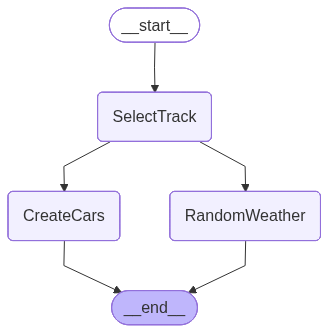

In [12]:
main_builder=StateGraph(GlobalState)

main_builder.add_node("SelectTrack", select_track)
main_builder.add_node("RandomWeather", random_weather)
main_builder.add_node("CreateCars", create_cars)

main_builder.add_edge(START,"SelectTrack")

main_builder.add_edge("SelectTrack","RandomWeather")
main_builder.add_edge("SelectTrack","CreateCars")

main_builder.add_edge("RandomWeather",END)
main_builder.add_edge("CreateCars",END)

graph = main_builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
SampleInput = {
    "Cars": "",
    "Track": "",
    "Weather": None,
    "CurrentLap": 0,
    "TotalLaps": 20,
    "RaceOver": False
}


result = graph.invoke(SampleInput)

In [14]:
print(result)

{'Cars': [{'CarPosition': 1, 'CarID': 4, 'Team': 'McLaren', 'Telemetry': None, 'Driver': 'Lando Norris', 'TotalRaceTime': 0.0, 'isUser': False}, {'CarPosition': 2, 'CarID': 1, 'Team': 'RedBull', 'Telemetry': None, 'Driver': 'Max Verstappen', 'TotalRaceTime': 0.0, 'isUser': False}, {'CarPosition': 3, 'CarID': 63, 'Team': 'Mercedes', 'Telemetry': None, 'Driver': 'George Russell', 'TotalRaceTime': 0.0, 'isUser': False}, {'CarPosition': 4, 'CarID': 81, 'Team': 'McLaren', 'Telemetry': None, 'Driver': 'Oscar Piastri', 'TotalRaceTime': 0.0, 'isUser': False}, {'CarPosition': 5, 'CarID': 12, 'Team': 'Mercedes', 'Telemetry': None, 'Driver': 'Andrea Kimi Antonelli', 'TotalRaceTime': 0.0, 'isUser': True}, {'CarPosition': 6, 'CarID': 22, 'Team': 'RedBull', 'Telemetry': None, 'Driver': 'Yuki Tsunoda', 'TotalRaceTime': 0.0, 'isUser': False}], 'Track': '', 'Weather': None, 'CurrentLap': 0, 'TotalLaps': 20, 'RaceOver': False}
